In [1]:
%reload_ext autoreload
%autoreload 2

In [2]:
import ast

import matplotlib.pyplot as plt

from tabpfn_sbi.utils.plot_utils import DEFAULT_COLORS, query, use_style

In [3]:
name = "../../main_results/ordering"
query(name, metric="c2st").head(10)

(metric=='c2st')


,method,estimator,embedding_net,task,num_simulations,seed,model_id,observation_ids,metric,value,time_train,time_eval,cfg
0,filtered_tabpfn,none,none,simple_nonlinear,100,0,87b4011c-1e92-4fb9-a37b-c814dfdcc09e,"[1, 2, 3, 4, 5, 6, 7, 8, 9, 10]",c2st,0.610420,0.054263,25.428374,"{'name': 'ordering', 'seed': 0, 'model_id': No..."
1,filtered_tabpfn,none,none,simple_nonlinear,100,2,b14dc461-91c4-44c6-bede-86ea5287c1af,"[1, 2, 3, 4, 5, 6, 7, 8, 9, 10]",c2st,0.594185,0.076896,26.127958,"{'name': 'ordering', 'seed': 2, 'model_id': No..."
2,filtered_tabpfn,none,none,simple_nonlinear,100,1,e8b7321a-3b61-47db-840b-19551d1552ac,"[1, 2, 3, 4, 5, 6, 7, 8, 9, 10]",c2st,0.585735,0.076129,27.892507,"{'name': 'ordering', 'seed': 1, 'model_id': No..."
3,filtered_tabpfn,none,none,simple_nonlinear,1000,1,6636f2c5-76d5-469b-a80b-5080f8e2586c,"[1, 2, 3, 4, 5, 6, 7, 8, 9, 10]",c2st,0.531380,0.591581,29.217114,"{'name': 'ordering', 'seed': 1, 'model_id': No..."
4,filtered_tabpfn,none,none,simple_nonlinear,1000,2,e155794e-8224-408a-98c5-35d2b1fb6ac0,"[1, 2, 3, 4, 5, 6, 7, 8, 9, 10]",c2st,0.524520,0.590832,28.241931,"{'name': 'ordering', 'seed': 2, 'model_id': No..."
5,filtered_tabpfn,none,none,simple_nonlinear,1000,0,3cd989fd-2775-4a59-8ea2-e72968942c2d,"[1, 2, 3, 4, 5, 6, 7, 8, 9, 10]",c2st,0.523610,0.582543,29.957560,"{'name': 'ordering', 'seed': 0, 'model_id': No..."
6,filtered_tabpfn,none,none,simple_nonlinear,10000,1,bbcb1dd5-3859-44dd-b033-9f9bc9871a9b,"[1, 2, 3, 4, 5, 6, 7, 8, 9, 10]",c2st,0.516460,5.765831,47.263113,"{'name': 'ordering', 'seed': 1, 'model_id': No..."
7,filtered_tabpfn,none,none,simple_nonlinear,10000,0,03bc1547-8014-47e4-b04e-3a6003caa64f,"[1, 2, 3, 4, 5, 6, 7, 8, 9, 10]",c2st,0.512920,5.746838,48.381708,"{'name': 'ordering', 'seed': 0, 'model_id': No..."
8,filtered_tabpfn,none,none,simple_nonlinear,10000,2,7b4d0076-affc-4678-a064-81670613ded6,"[1, 2, 3, 4, 5, 6, 7, 8, 9, 10]",c2st,0.511810,5.777624,49.850861,"{'name': 'ordering', 'seed': 2, 'model_id': No..."
9,filtered_tabpfn,none,none,simple_nonlinear,100,0,147daeac-c658-499e-ad97-ad4c2e4f7d73,"[1, 2, 3, 4, 5, 6, 7, 8, 9, 10]",c2st,0.612920,0.054281,25.419233,"{'name': 'ordering', 'seed': 0, 'model_id': No..."


In [4]:
fig_size = (1.1, 1.0)
df = query(name)

# add keys
cfg_dicts = df["cfg"].apply(ast.literal_eval)

# Extract nested parameters from cfg.task.params
df["permutation"] = cfg_dicts.apply(lambda x: x["task"]["params"]["permutation"])
# df['n_output_dim'] = cfg_dicts.apply(lambda x: x['task']['params']['n_output_dim']) # only for handcrafted tasks
# df['task_name'] = cfg_dicts.apply(lambda x: x['task']['params']['task_name']) # only for sbibm tasks

/tmp/ipykernel_3185218/3848397975.py:17: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  task_df["n_output_dim"] = cfg_dicts.apply(
/tmp/ipykernel_3185218/3848397975.py:17: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  task_df["n_output_dim"] = cfg_dicts.apply(


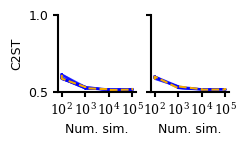

In [5]:
tasks = [
    "simple_nonlinear",
    "mixed_dist",
]
methods = ["filtered_tabpfn"]

with use_style("pyloric"):
    num_tasks = len(tasks)
    fig, axes = plt.subplots(
        1, num_tasks, figsize=(num_tasks * fig_size[0], fig_size[1]), sharey=True
    )

    for i, task in enumerate(tasks):
        task_df = df[df["task"] == task]

        cfg_dicts = task_df["cfg"].apply(ast.literal_eval)
        task_df["n_output_dim"] = cfg_dicts.apply(
            lambda x: x["task"]["params"]["n_output_dim"]
        )

        # Plot permuted results in gray
        default_perm = list(range(task_df["n_output_dim"].iloc[0]))
        is_permuted = task_df["permutation"].apply(lambda x: x != default_perm)
        permuted_df = task_df[is_permuted]

        unique_permutations = permuted_df["permutation"].apply(tuple).unique()
        unique_permutations = [
            list(p) for p in unique_permutations
        ]  # Convert back to lists if needed

        for j, perm in enumerate(unique_permutations):
            is_perm = permuted_df["permutation"].apply(lambda x: x == perm)
            perm_df = permuted_df[is_perm]
            perm_df = perm_df.sort_values("num_simulations")

            axes[i].plot(
                perm_df["num_simulations"],
                perm_df["value"],
                color="blue",
                alpha=0.7,
                label="permuted" if j == 0 else None,
            )

        # Plot default ordering in TabPFN color
        default_df = task_df[~is_permuted]
        default_df = default_df.sort_values("num_simulations")
        axes[i].plot(
            default_df["num_simulations"],
            default_df["value"],
            color=DEFAULT_COLORS["filtered_tabpfn"],
            label="default",
            linestyle="dashed",
        )

        # axes[i].set_title(task.replace("_", " ").title())
        axes[i].set_xlabel("Num. sim.")
        axes[i].set_ylabel("C2ST") if i == 0 else None
        axes[i].set_ylim(0.5, 1)
        axes[i].set_xscale("log")
        axes[i].minorticks_off()
        axes[i].set_xticks([10**2, 10**3, 10**4, 10**5])
        axes[i].set_xticklabels(["$10^2$", "$10^3$", "$10^4$", "$10^5$"])

    axes[0].set_yticks([0.5, 1.0])
    fig.savefig(f"fig_ordering_base_handcrafted.svg", bbox_inches="tight")

/tmp/ipykernel_3185218/3357035978.py:17: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_updated["task_name"] = cfg_dicts.apply(


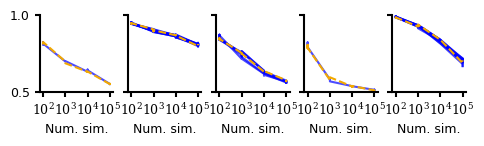

In [6]:
tasks = [
    "permuted_task",
]
task_names = [
    "two_moons",
    "slcp",
    "bernoulli_glm",
    "sir",
    "lotka_volterra",
]
methods = ["filtered_tabpfn"]

with use_style("pyloric"):
    df_updated = df[df["task"] == tasks[0]]
    cfg_dicts = df_updated["cfg"].apply(ast.literal_eval)
    df_updated["task_name"] = cfg_dicts.apply(
        lambda x: x["task"]["params"]["task_name"]
    )  # only for sbibm tasks

    num_tasks = len(task_names)
    fig, axes = plt.subplots(
        1, num_tasks, figsize=(num_tasks * fig_size[0], fig_size[1]), sharey=True
    )
    for i, task_name in enumerate(task_names):
        task_df = df_updated[df_updated["task_name"] == task_name]

        n_output_dim = len(task_df["permutation"].iloc[0])
        # Plot permuted results in gray
        default_perm = list(range(n_output_dim))
        is_permuted = task_df["permutation"].apply(lambda x: x != default_perm)
        permuted_df = task_df[is_permuted]

        unique_permutations = permuted_df["permutation"].apply(tuple).unique()
        unique_permutations = [
            list(p) for p in unique_permutations
        ]  # Convert back to lists if needed

        for j, perm in enumerate(unique_permutations):
            is_perm = permuted_df["permutation"].apply(lambda x: x == perm)
            perm_df = permuted_df[is_perm]
            perm_df = perm_df.sort_values("num_simulations")

            axes[i].plot(
                perm_df["num_simulations"],
                perm_df["value"],
                color="blue",
                alpha=0.7,
                label="permuted" if j == 0 else None,
            )

        # Plot default ordering in TabPFN color
        default_df = task_df[~is_permuted]
        default_df = default_df.sort_values("num_simulations")
        axes[i].plot(
            default_df["num_simulations"],
            default_df["value"],
            color=DEFAULT_COLORS["filtered_tabpfn"],
            label="default",
            linestyle="dashed",
        )

        axes[i].set_xlabel("Num. sim.")

        axes[i].set_ylim(0.5, 1)
        axes[i].set_xscale("log")
        axes[i].minorticks_off()
        axes[i].set_xticks([10**2, 10**3, 10**4, 10**5])
        axes[i].set_xticklabels(["$10^2$", "$10^3$", "$10^4$", "$10^5$"])

    axes[0].set_yticks([0.5, 1.0])
    fig.savefig(f"fig_ordering_base_sbibm.svg", bbox_inches="tight")

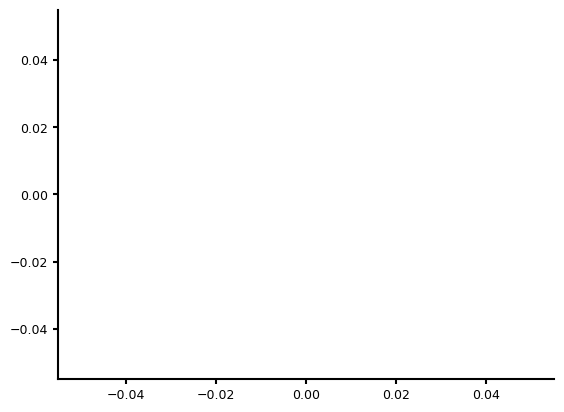

In [7]:
def save_legend():
    # Create handles for the legend
    with use_style("pyloric"):
        legend_handles = []
        legend_labels = []

        # Add method handles
        (permuted_handle,) = plt.plot([], [], color="blue", linestyle="-", marker="s")
        (default_handle,) = plt.plot(
            [], [], color=DEFAULT_COLORS["filtered_tabpfn"], linestyle="--", marker="o"
        )
        legend_handles.extend([permuted_handle, default_handle])
        legend_labels.extend(["permuted", "default"])

        # Create and save the legend
        fig_legend = plt.figure(figsize=(1.5, 0.7))
        ax = fig_legend.add_subplot(111)
        ax.legend(
            legend_handles, legend_labels, loc="center", ncol=4
        )  # Set ncol=4 to have all items in one row
        ax.axis("off")
        fig_legend.savefig("legend_only.svg", bbox_inches="tight", transparent=True)
        # plt.show()
        plt.close()


save_legend()